In [54]:
import pandas as pd
import numpy as np

In [86]:
distributions_input = pd.read_csv('data/distributions_inputfile.csv').dropna(subset=['ncol'])
distributions_input

,ncol,nrow,population,allroads,mainroads,secroads,industries,traffic_points
0,1.0,1.0,63.0,0.0,0.0,0.0,0.0,0.0
1,2.0,1.0,95.0,0.0,0.0,0.0,0.0,0.0
2,3.0,1.0,76.0,0.0,0.0,0.0,0.0,0.0
3,4.0,1.0,92.0,0.0,0.0,0.0,0.0,0.0
4,5.0,1.0,709.0,0.0,2.5,0.0,0.5,2.0
...,...,...,...,...,...,...,...,...
2495,46.0,50.0,396.0,1.2,0.0,0.0,0.0,0.0
2496,47.0,50.0,932.0,0.3,2.4,0.0,0.5,1.0
2497,48.0,50.0,1617.0,0.3,1.1,0.0,0.0,0.0
2498,49.0,50.0,82.0,0.0,0.3,0.0,0.0,0.0


In [56]:
# Get all emission sources
sources = distributions_input.columns.drop(['ncol','nrow'])
sources

Index(['population', 'allroads', 'mainroads', 'secroads', 'industries',
       'traffic_points'],
      dtype='object')

In [57]:
total_emissions = 5000 #tonnes

In [58]:
# Assign source contribution to the total emissions in percentages - in the order of sources listed - 
# use scroll bars for each source to get this as user input 
source_contributions = np.array([0.3, 0.2, 0.1, 0.1, 0.2, 0.1])

In [59]:
#Ensure that source_contributions sums up to 100%
total = source_contributions.sum()
if round(total,3)!=1:
    print("Ensure that sum contributions is 100%")

In [60]:
# Normalise all source values in each cell
for source in sources:
    layer_sum = distributions_input[source].sum()
    distributions_input[source] = distributions_input[source]/layer_sum

In [61]:
# Cell wise emissions: Compute the weighted sum of normalised ccontributions
distributions_input['emission'] = distributions_input[sources].mul(source_contributions).sum(axis=1) * total_emissions

In [63]:
distributions_input

,ncol,nrow,population,allroads,mainroads,secroads,industries,traffic_points,emission
0,1.0,1.0,0.000007,0.000000,0.000000,0.0,0.00000,0.000000,0.011181
1,2.0,1.0,0.000011,0.000000,0.000000,0.0,0.00000,0.000000,0.016861
2,3.0,1.0,0.000009,0.000000,0.000000,0.0,0.00000,0.000000,0.013489
3,4.0,1.0,0.000011,0.000000,0.000000,0.0,0.00000,0.000000,0.016328
4,5.0,1.0,0.000084,0.000000,0.001953,0.0,0.00045,0.000145,1.624847
...,...,...,...,...,...,...,...,...,...
2495,46.0,50.0,0.000047,0.000274,0.000000,0.0,0.00000,0.000000,0.344244
2496,47.0,50.0,0.000110,0.000068,0.001875,0.0,0.00045,0.000072,1.657687
2497,48.0,50.0,0.000191,0.000068,0.000859,0.0,0.00000,0.000000,0.785202
2498,49.0,50.0,0.000010,0.000000,0.000234,0.0,0.00000,0.000000,0.131750


In [83]:
ncol_max = distributions_input.ncol.max()
nrow_max = distributions_input.nrow.max()

grid_array = np.array(distributions_input.sort_values(by=['ncol','nrow'], ascending=False)['emission']).reshape(int(ncol_max),int(nrow_max))

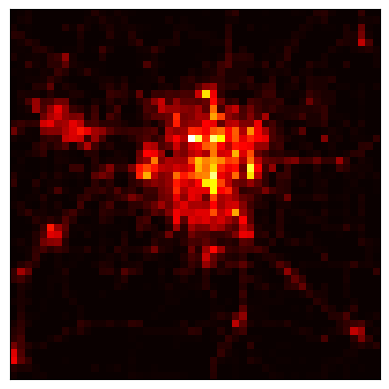

In [85]:
import matplotlib.pyplot as plt
import numpy as np

plt.imshow(grid_array, cmap='hot', interpolation='nearest')
plt.xticks([])  # Remove x-axis ticks
plt.yticks([])  # Remove y-axis ticks
plt.show()

In [81]:
grid_array

array([[1.11814722e-02, 1.68609502e-02, 1.34887601e-02, ...,
        3.21245472e-02, 6.06355622e-01, 1.97006891e-02],
       [4.73452217e-02, 2.20079771e-02, 3.26569982e-02, ...,
        3.34474970e-01, 4.29975694e-01, 4.06437641e-02],
       [2.68000366e-02, 1.72869110e-01, 7.88027566e-02, ...,
        4.93448123e+00, 8.02068498e-01, 2.13141551e+00],
       ...,
       [1.06490212e-01, 1.03211958e+00, 2.23932617e+00, ...,
        1.82985680e-01, 8.20684564e-01, 6.44533755e-01],
       [5.23576874e-02, 8.91312648e-01, 4.48352507e+00, ...,
        1.07910081e-01, 5.32503267e-01, 1.73458984e-01],
       [6.34714729e-01, 1.57107722e+00, 1.24169672e+01, ...,
        7.85202215e-01, 1.31750318e-01, 5.62623285e-02]])